# Dock generated molecules with Autodock Vina

## set-up

This block:

- Loads all needed modules/libraries
    
- reads in the datafile containing the SMILES strings, IC50's and Temperature
    


In [1]:
!pip install deepchem
!pip install dockstring
! pip install openbabel-wheel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 88.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import deepchem as dc
import time
from rdkit import Chem
import matplotlib.pyplot as plt
from rdkit.Chem import AllChem, Draw
from deepchem.feat.smiles_tokenizer import SmilesTokenizer
from dockstring import load_target
from google.colab import files

wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


## Function to save pose as SDF file

In [4]:
def save_pose(pose_mol,pose_score, index):
  pose_mol.SetProp('_Name',str(pose_score))
  sdf_filename = base+"_"+str(score)+"_"+str(index)+".sdf"
  w = Chem.SDWriter(sdf_filename)
  w.write(pose_mol)
  w.close
  print(sdf_filename)
  files.download(sdf_filename)
  print(f"SDF file written for score {pose_score}")

## Dock molecules generated with Autodock via dockstring
- Reading in molecules generated by GPT with predicted IC50
- Using dockstring to dock in protein, using Autodock Vina
- checks the score store for pre-computed docking scores

In [5]:
df_score_store = pd.read_csv("/content/Docking_scores_no_dupes_V2.csv")
stored_scores_list = df_score_store["Score"].to_list()
stored_smiles_list = df_score_store["SMILES"].to_list()

In [16]:
which_statin = 663
filename = f"/content/statin{which_statin}fullgen15p_IC50.csv"
df = pd.read_csv(f"/content/statin{which_statin}fullgen15p_IC50.csv")

In [17]:
count = df.shape[0]

print(f"Docking {count} molecules in HMGCR.")
target = load_target("HMGCR")

i = 0
saved_index = 1
average_score = 0.0
score_count = 0
scores_list = []
for name, smile in zip(df["IC50"],df["SMILES"]):
    print(f"Docking {i}. \r")
    try:
      if smile in stored_smiles_list:
        stored_index = stored_smiles_list.index(smile)
        score = stored_scores_list[stored_index]
        print(f"Docking score for {i} : {name} is {score}, obtained from score store.")
      else:
        score, aux = target.dock(smile, num_cpus = 2)
        print(f"Docking score for {i} : {name} is {score}")

      scores_list.append(score)
      if score != 0.0:
        average_score += score
        score_count += 1
    except:
      print(f"Molecule {i} could not be docked!")
      scores_list.append(0.0)
    i += 1

print(f"Average Score for dockable molecules is: {average_score/score_count}")

Docking 40 molecules in HMGCR.
Docking 0. 
Docking score for 0 : 2.9294827 is -9.1
Docking 1. 
Docking score for 1 : 593.8041 is -9.3
Docking 2. 
Docking score for 2 : 29.585766 is -8.9
Docking 3. 
Docking score for 3 : 93.463356 is -8.8
Docking 4. 
Docking score for 4 : 367.91595 is -8.1
Docking 5. 
Docking score for 5 : 394.37796 is -9.2
Docking 6. 


[18:47:06] Explicit valence for atom # 33 C, 5, is greater than permitted


Molecule 6 could not be docked!
Docking 7. 
Docking score for 7 : 89.152664 is -8.5
Docking 8. 


[18:56:38] Explicit valence for atom # 33 C, 5, is greater than permitted


Molecule 8 could not be docked!
Docking 9. 


...

Molecule 26 could not be docked!
Docking 27. 


[20:21:30] Explicit valence for atom # 33 C, 5, is greater than permitted


Molecule 27 could not be docked!
Docking 28. 
Docking score for 28 : 1821.112 is -8.7
Docking 29. 
Docking score for 29 : 174.39505 is -8.4
Docking 30. 


[20:34:45] Explicit valence for atom # 33 C, 5, is greater than permitted


Molecule 30 could not be docked!
Docking 31. 
Docking score for 31 : 426.84796 is -8.8
Docking 32. 
Docking score for 32 : 2416.322 is -8.5
Docking 33. 
Docking score for 33 : 707.16364 is -8.2
Docking 34. 
Docking score for 34 : 14.657737 is -8.6
Docking 35. 
Docking score for 35 : 158.17915 is -7.9
Docking 36. 
Docking score for 36 : 30.219435 is -8.4
Docking 37. 
Docking score for 37 : 1585.417 is -8.5
Docking 38. 
Docking score for 38 : 444.4784 is -8.6
Docking 39. 
Docking score for 39 : 394.37796 is -9.2
Average Score for dockable molecules is: -8.628124999999999


## Calculate the Quantitative Estimate of Drug-Likeness (QED)
- set to default but can use weights_mean, weights_max, or weights_none
- properties: MW aLogP HBA HBD PolarSurfaceArea RotBond AromRings Alerts

In [18]:
qed_list = []
MW_list = []
aLogP_list = []
HBA_list = []
HBD_list = []
RotBond_list = []
AromRings_list = []

#print_score = old_scores + print_score

for smile,ic50 in zip(df["SMILES"],df["IC50"]):
  try:
    mol = Chem.MolFromSmiles(smile)
    qed_descriptor = Chem.QED.default(mol)
    p = Chem.QED.properties(mol)
    qed_list.append(qed_descriptor)
    MW_list.append(p[0])
    aLogP_list.append(p[1])
    HBA_list.append(p[2])
    HBD_list.append(p[3])
    RotBond_list.append(p[5])
    AromRings_list.append(p[6])
  except:
    qed_list.append(0.0)
    MW_list.append(0.0)
    aLogP_list.append(0.0)
    HBA_list.append(0.0)
    HBD_list.append(0.0)
    RotBond_list.append(0.0)
    AromRings_list.append(0.0)
    print(f"Could not calculate QED for {smile}")

print(f"Average QED: {sum(qed_list)/len(qed_list)}")
print(f"Average MW: {sum(MW_list)/len(MW_list)}")
print(f"Average aLogP: {sum(aLogP_list)/len(aLogP_list)}")
print(f"Average HBA: {sum(HBA_list)/len(HBA_list)}")
print(f"Average HBD: {sum(HBD_list)/len(HBD_list)}")
print(f"Average RotBond: {sum(RotBond_list)/len(RotBond_list)}")
print(f"Average AromRings: {sum(AromRings_list)/len(AromRings_list)}")

print_dictionary = {"IC50": df["IC50"], "QED": qed_list, "SMILES": df["SMILES"],
                    "MW": MW_list, "aLogP": aLogP_list, "HBA": HBA_list,
                    "HBD": HBD_list, "RotBond": RotBond_list, "AromRings": AromRings_list,
                    "Score": scores_list, "SAS": df["SAS"], "SIMILARITY": df["SIMILARITY"]}

outfile_name = f"statin{which_statin}fullgen15p_ALLPROPS.csv"
print(outfile_name)
print_df = pd.DataFrame.from_dict(print_dictionary)
print_df.to_csv(outfile_name, index=False)
print("Outputfile saved!")
files.download(outfile_name)

Average QED: 0.26245003189214294
Average MW: 536.9593000000002
Average aLogP: 5.607810000000006
Average HBA: 4.4
Average HBD: 0.975
Average RotBond: 10.525
Average AromRings: 3.8
statin663fullgen15p_ALLPROPS.csv
Outputfile saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Read in a file and get averages

In [19]:
df2 = pd.read_csv(outfile_name)
print(len(df2))
df3 = df2[df2["Score"] != 0.0]
print(len(df3.iloc[1:]))
df3.iloc[1:].describe()

40
31


,IC50,QED,MW,aLogP,HBA,HBD,RotBond,AromRings,Score,SAS,SIMILARITY
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.0,31.000000,31.000000,31.000000
mean,494.615467,0.219936,539.884806,6.095029,4.096774,0.806452,10.677419,4.0,-8.612903,3.817465,0.742212
std,614.341854,0.051610,11.899779,1.059516,0.870051,0.833441,1.469401,0.0,0.391358,0.201888,0.057775
min,14.657737,0.151063,517.624000,3.472600,3.000000,0.000000,5.000000,4.0,-9.300000,3.504053,0.493671
25%,91.308010,0.171704,533.667000,5.628950,3.500000,0.000000,10.000000,4.0,-8.800000,3.750582,0.723881
50%,311.194900,0.210524,535.639000,6.110000,4.000000,1.000000,11.000000,4.0,-8.600000,3.807824,0.746269
75%,549.157480,0.241932,550.698000,6.841600,5.000000,1.000000,12.000000,4.0,-8.400000,3.893956,0.776923
max,2416.322000,0.328399,564.701000,7.690700,6.000000,3.000000,12.000000,4.0,-7.800000,4.631297,0.818898


## Draw the molecules generated

- Molecules generated in the block above can be visualized here.
- Molecules start after th [CLS] token, and go until the [SEP] or [PAD] token.

Molecules generated by SO5K6S_0p5_Docking_Molecules
Legend = [predicted IC50 in nM] and docking score
Average IC50 for 98 molecules is: 128.82495032857136 nM


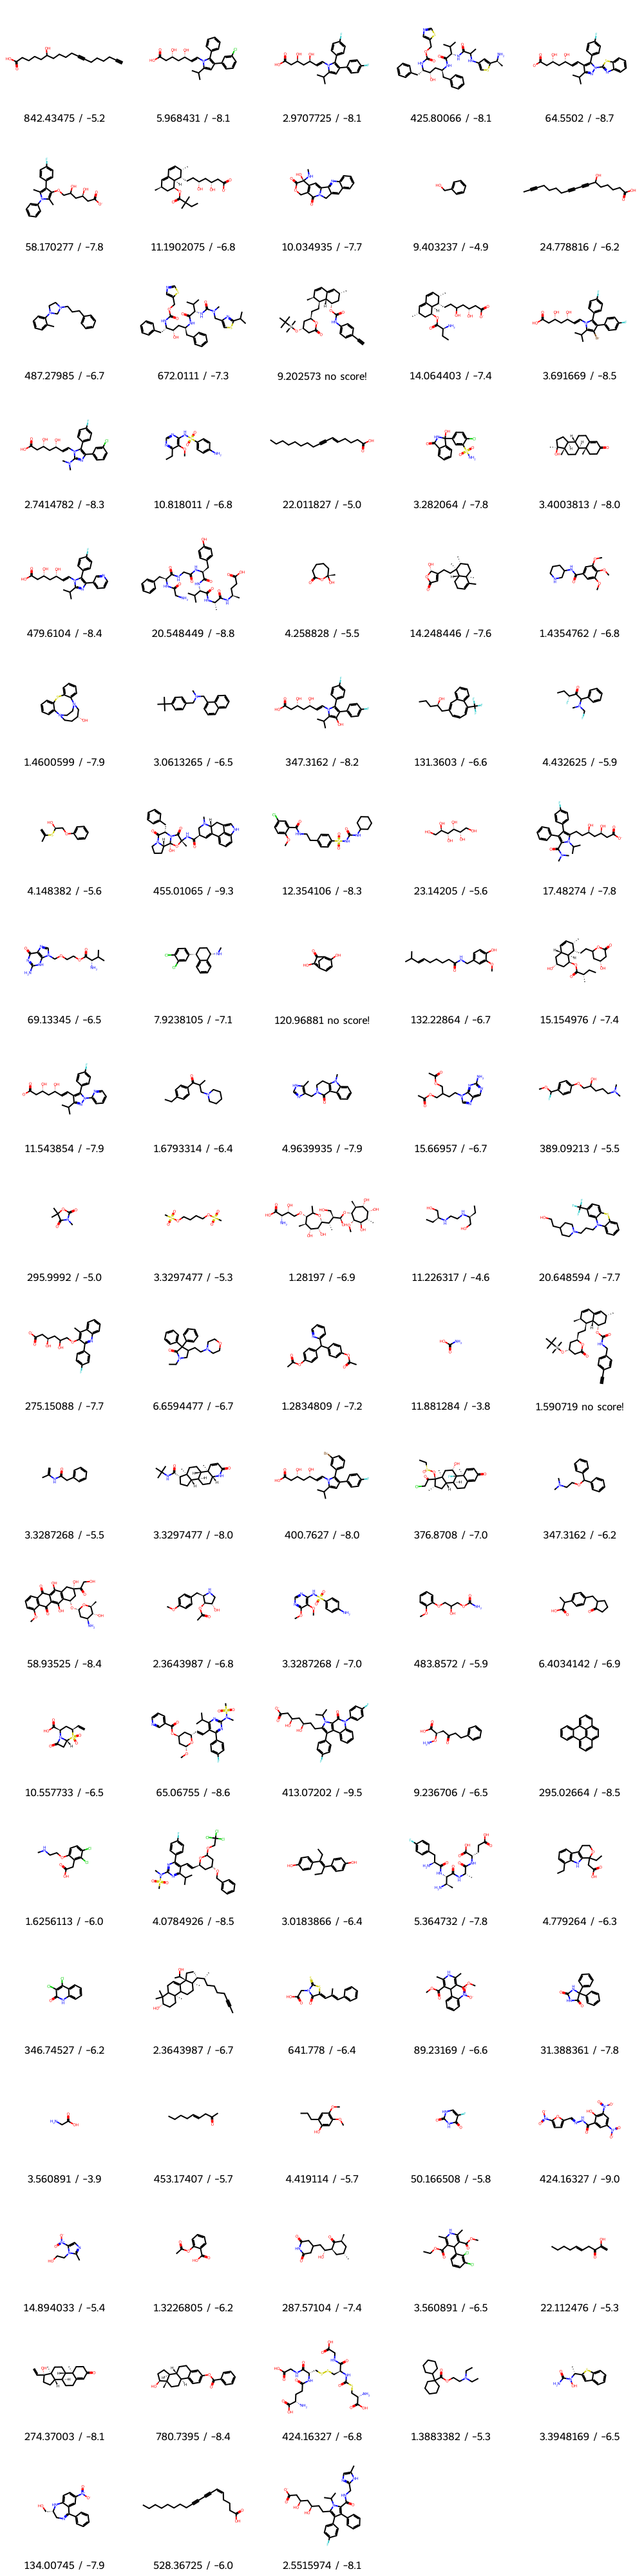

In [ ]:
print_mols = []
for ti, smile in enumerate(df["SMILES"]):
       temp_mol = Chem.MolFromSmiles(smile)
       print_mols.append(temp_mol)

print(f"Molecules generated by "+base)
print("Legend = [predicted IC50 in nM] and docking score")
print(f"Average IC50 for {count} molecules is: {average_ic50} nM")

Draw.MolsToGridImage(mols=print_mols, legends = print_legend, molsPerRow=5,maxMols=500)

## Plot scores versus IC50 and find best fit line

In [ ]:
dft = pd.read_csv("/content/1X_0p0_Docking_Molecules_QED_props.csv")
dft["Score"].mean()

-7.554054054054053

In [ ]:
print_ic50.pop(4)

6.802234161539646

In [ ]:
print_score.pop(4)

''

ValueError: x and y must be the same size

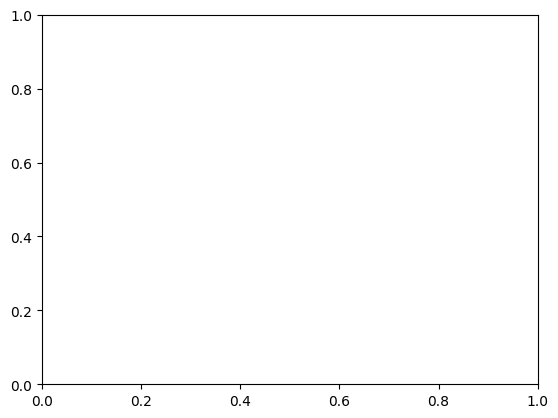

In [ ]:
import matplotlib.pyplot as plt

print_ic50 = list(map(lambda x: np.log(float(x)),print_legend_1))
i=0
for ic50,score in zip(print_ic50,print_score):
  if score == 0.0:
    print_ic50.pop(i)
    print_score.pop(i)
    print(f"removed value {i}")
  i += 1
plt.scatter(print_ic50,print_score,color="blue")

a, b = np.polyfit(print_ic50,print_score, 1)
fit_ic50 = list(map(lambda x: a*x+b,print_ic50))
correlation = np.corrcoef(print_ic50,print_score)[0,1]
rsquared = correlation**2
plt.plot(print_ic50,fit_ic50,color="green")

plt.xlabel("Predicted ln(Ic50) (nM)")
plt.ylabel("Docking Score (kcal/mol)")
plt.title(f'score = {a} ic50 + {b} \n     R^2 = {rsquared}')
pic_name = outfile_name.replace(".csv",".jpg")
plt.savefig(pic_name)
plt.show()